# Stage 1 — Pre-training

Predict the next token on a tiny corpus. This is the *foundation* of every reasoning model: before you can teach a model to reason, you need a model that speaks the language.

We train a 2-layer character-level transformer on a snippet of Shakespeare for 200 steps.

In [1]:
import torch, torch.nn as nn, torch.nn.functional as F
torch.manual_seed(0)

TEXT = (
    'To be, or not to be, that is the question:\n'
    'Whether tis nobler in the mind to suffer\n'
    'The slings and arrows of outrageous fortune,\n'
    'Or to take arms against a sea of troubles\n'
    'And by opposing end them.\n'
) * 20

chars = sorted(set(TEXT))
stoi = {c: i for i, c in enumerate(chars)}
itos = {i: c for c, i in stoi.items()}
data = torch.tensor([stoi[c] for c in TEXT], dtype=torch.long)
V, BLOCK = len(chars), 32
print('vocab size:', V, '| dataset chars:', len(data))

vocab size: 30 | dataset chars: 3940


In [2]:
class TinyTransformer(nn.Module):
    def __init__(self, V, d=64, h=4, L=2, block=BLOCK):
        super().__init__()
        self.tok = nn.Embedding(V, d)
        self.pos = nn.Embedding(block, d)
        self.blocks = nn.ModuleList([nn.TransformerEncoderLayer(d, h, dim_feedforward=4*d, batch_first=True, activation='gelu') for _ in range(L)])
        self.head = nn.Linear(d, V)
    def forward(self, x):
        B, T = x.shape
        h = self.tok(x) + self.pos(torch.arange(T, device=x.device))
        mask = nn.Transformer.generate_square_subsequent_mask(T).to(x.device)
        for blk in self.blocks:
            h = blk(h, src_mask=mask)
        return self.head(h)

model = TinyTransformer(V)
opt = torch.optim.AdamW(model.parameters(), lr=3e-3)
print('params:', sum(p.numel() for p in model.parameters())/1e3, 'K')

params: 105.886 K


In [3]:
def get_batch(bs=16):
    ix = torch.randint(0, len(data) - BLOCK - 1, (bs,))
    x = torch.stack([data[i:i+BLOCK] for i in ix])
    y = torch.stack([data[i+1:i+BLOCK+1] for i in ix])
    return x, y

losses = []
for step in range(200):
    x, y = get_batch()
    logits = model(x)
    loss = F.cross_entropy(logits.view(-1, V), y.view(-1))
    opt.zero_grad(); loss.backward(); opt.step()
    losses.append(loss.item())
    if step % 40 == 0:
        print(f'step {step:3d}  loss {loss.item():.3f}')

step   0  loss 3.425


step  40  loss 1.389


step  80  loss 0.698


step 120  loss 0.370


step 160  loss 0.263


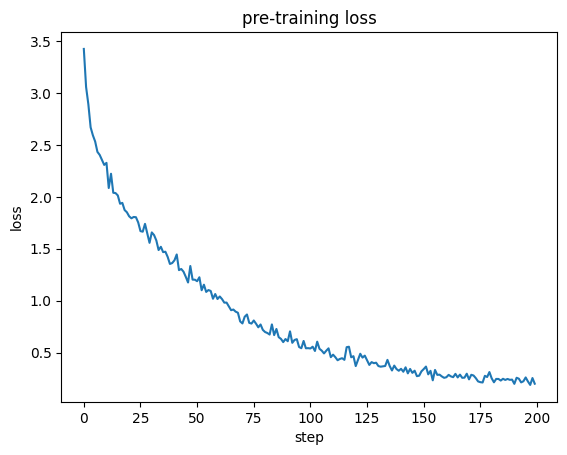

In [4]:
import matplotlib.pyplot as plt
plt.plot(losses); plt.xlabel('step'); plt.ylabel('loss'); plt.title('pre-training loss'); plt.show()

In [5]:
@torch.no_grad()
def sample(prompt='To be', n=80):
    x = torch.tensor([[stoi[c] for c in prompt]])
    for _ in range(n):
        logits = model(x[:, -BLOCK:])[:, -1, :]
        nxt = torch.multinomial(F.softmax(logits, -1), 1)
        x = torch.cat([x, nxt], 1)
    return ''.join(itos[i.item()] for i in x[0])

print(sample())

To be, or nobe, to be, that is the question:tis nos the,
Wher tinot the ques fortr
Th


## Takeaway

200 steps is enough to start producing Shakespeare-flavored gibberish. Real pre-training is the same loss, just with billions of tokens and parameters.

**This is the base model.** Everything in stages 2–5 modifies *this*.